# CIS 509 – Project Exploratory Data Analysis

## Understanding Customer Sentiment in Nashville Music Venues Using Yelp Reviews (2013–2019)

## 1. **Team ID:** Team 1  
## 2. **Team Members:**  Meshach Samuel, Terence Roberts, Rigas-Ioannis Vancham-Parpouras, Ricardo Gonzalez, Venkata Batchu

## 3. Executive Summary

This project analyzes Yelp reviews of Nashville music venues (2013–2019) to build a turnaround playbook for operators and investors. Using VADER + topic modeling on 1–2★ reviews, we separate fixable operational friction (e.g., lines, service, pricing) from structural constraints (e.g., location, acoustics), then compute a subtype-level Actionability Index over time to identify where quick, high-confidence improvements are most likely.

## 4. Data Sources & Filtering Criteria

In [40]:
# ── Imports ──────────────────────────────────────────────────────────
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

# NLP
import nltk
nltk.download('vader_lexicon', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Topic modeling
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120

In [41]:
# ── Load business data ───────────────────────────────────────────────
# UPDATE THIS PATH to wherever your Yelp data lives
DATA_DIR = './'  # <-- change if needed

businesses = []
with open(f'{DATA_DIR}yelp_academic_dataset_business.json', 'r', encoding='utf-8') as f:
    for line in f:
        businesses.append(json.loads(line))
biz_df = pd.DataFrame(businesses)
print(f'Total businesses in file: {len(biz_df):,}')

Total businesses in file: 150,346


In [42]:
# ── Filter to Music Venues ───────────────────────────────────────────
biz_df['categories_list'] = biz_df['categories'].fillna('').str.lower().str.split(', ')
music_biz = biz_df[biz_df['categories_list'].apply(lambda cats: 'music venues' in cats)].copy()

print(f'Music Venue businesses (all locations): {len(music_biz):,}')

Music Venue businesses (all locations): 1,104


In [43]:
# ── Filter to Nashville, TN only ─────────────────────────────────────────
nash_biz = music_biz[
    (music_biz['city'].str.strip().str.lower() == 'nashville') &
    (music_biz['state'].str.strip().str.upper() == 'TN')
].copy()

print(f'Nashville Music Venue businesses: {len(nash_biz):,}')
print(f'Nashville Music Venue business_ids: {nash_biz["business_id"].nunique():,}')

Nashville Music Venue businesses: 151
Nashville Music Venue business_ids: 151


In [44]:
# ── Load reviews for Nashvile businesses ─────────────────────────────────────────────────────
nash_biz_ids = set(nash_biz['business_id'])

reviews = []
with open(f'{DATA_DIR}yelp_academic_dataset_review.json', 'r', encoding='utf-8') as f:
    for line in f:
        r = json.loads(line)
        if r['business_id'] in nash_biz_ids:
            reviews.append(r)

rev_df = pd.DataFrame(reviews)
rev_df['date'] = pd.to_datetime(rev_df['date'])
rev_df['year'] = rev_df['date'].dt.year

print(f'Total Nashville Music Venue reviews (all years): {len(rev_df):,}')
print(f'Year range: {rev_df["year"].min()} - {rev_df["year"].max()}')

# Save for later consolidated verification
rev_all_years_count = len(rev_df)

Total Nashville Music Venue reviews (all years): 25,892
Year range: 2005 - 2022


In [45]:
# ── Filter to 2013–2019, deduplicate, and print verification stats ─────────────────────────────────
rev_df = rev_df[(rev_df['year'] >= 2013) & (rev_df['year'] <= 2019)].copy()
rev_df = rev_df.drop_duplicates(subset='review_id')
print(f'Nashville Music Venue reviews 2013–2019 (deduplicated): {len(rev_df):,}')
print(f'Unique reviewers: {rev_df["user_id"].nunique():,}')
print(f'Unique businesses: {rev_df["business_id"].nunique():,}')

print(f'Date range: {rev_df["date"].min().date()} to {rev_df["date"].max().date()}')

print('\nReviews by year:')
print(rev_df['year'].value_counts().sort_index())

rev_df['month'] = rev_df['date'].dt.to_period('M').astype(str)
print('\nReviews by month (first 12 rows):')
print(rev_df['month'].value_counts().sort_index().head(12))

Nashville Music Venue reviews 2013–2019 (deduplicated): 18,925
Unique reviewers: 14,485
Unique businesses: 139
Date range: 2013-01-01 to 2019-12-31

Reviews by year:
year
2013    1583
2014    2137
2015    2535
2016    2548
2017    2661
2018    3794
2019    3667
Name: count, dtype: int64

Reviews by month (first 12 rows):
month
2013-01    107
2013-02    106
2013-03    137
2013-04    121
2013-05    144
2013-06    145
2013-07    138
2013-08    174
2013-09    145
2013-10    133
2013-11    125
2013-12    108
Name: count, dtype: int64


In [46]:
# ── Merge business metadata onto reviews and consolidated verification ─────────────────────────────
df = rev_df.merge(
    nash_biz[['business_id', 'name', 'categories', 'categories_list', 'stars', 'review_count', 'city', 'state']],
    on='business_id', how='left', suffixes=('_review', '_biz')
)

print(f'Merged dataset shape: {df.shape}')

print('\n=== Verification counts ===')
print(f'Total businesses in file: {len(biz_df):,}')
print(f'Music Venue businesses (all locations): {len(music_biz):,}')
print(f'Nashville Music Venue businesses: {nash_biz["business_id"].nunique():,}')
print(f'Nashville Music Venue reviews (all years): {rev_all_years_count:,}')
print(f'Nashville Music Venue reviews 2013–2019 (deduped): {len(rev_df):,}')
print(f'Unique reviewers (2013–2019): {rev_df["user_id"].nunique():,}')
print(f'Unique businesses (2013–2019): {rev_df["business_id"].nunique():,}')
print(f'Date range (2013–2019): {rev_df["date"].min().date()} to {rev_df["date"].max().date()}')

Merged dataset shape: (18925, 18)

=== Verification counts ===
Total businesses in file: 150,346
Music Venue businesses (all locations): 1,104
Nashville Music Venue businesses: 151
Nashville Music Venue reviews (all years): 25,892
Nashville Music Venue reviews 2013–2019 (deduped): 18,925
Unique reviewers (2013–2019): 14,485
Unique businesses (2013–2019): 139
Date range (2013–2019): 2013-01-01 to 2019-12-31


In [47]:
# ── Define venue subtypes from co-occurring Yelp categories ─────────
# Note: single-label subtype via FIRST-match priority order (interpretable heuristic).
def assign_subtype(cats):
    cats_lower = [c.strip().lower() for c in cats if isinstance(c, str)]

    # Specific first (avoid generic tags like "nightlife")
    if any(x in cats_lower for x in ['dance clubs', 'nightclubs', 'country dance halls']):
        return 'Dance/Club'
    elif any(x in cats_lower for x in ['venues & event spaces', 'event planning & services', 'party & event planning']):
        return 'Event Space'
    elif any(x in cats_lower for x in ['performing arts', 'concert halls', 'theaters', 'opera & ballet']):
        return 'Performance Hall/Theater'
    elif any(x in cats_lower for x in ['jazz & blues']):
        return 'Jazz/Blues'
    elif any(x in cats_lower for x in ['bars', 'pubs', 'sports bars', 'dive bars', 'cocktail bars', 'beer bar', 'wine bars', 'lounges']):
        return 'Bar-Oriented'
    elif any(x in cats_lower for x in ['restaurants', 'food', 'breakfast & brunch']):
        return 'Restaurant-Hybrid'
    else:
        return 'Other'

df['subtype'] = df['categories_list'].apply(assign_subtype)

print('Review counts by venue subtype:')
print(df['subtype'].value_counts())

print('\nUnique businesses by subtype:')
print(df.groupby('subtype')['business_id'].nunique().sort_values(ascending=False))


Review counts by venue subtype:
subtype
Bar-Oriented                9609
Event Space                 4102
Restaurant-Hybrid           2601
Jazz/Blues                   968
Other                        729
Performance Hall/Theater     714
Dance/Club                   202
Name: count, dtype: int64

Unique businesses by subtype:
subtype
Bar-Oriented                69
Event Space                 30
Other                       20
Restaurant-Hybrid            9
Dance/Club                   4
Performance Hall/Theater     4
Jazz/Blues                   3
Name: business_id, dtype: int64


### Data Sources Summary

**Primary data:** Yelp Open Dataset (`yelp_academic_dataset_business.json`, `yelp_academic_dataset_review.json`)

**Filtering criteria applied:**
1. Business categories contains "Music Venues"
2. City = Nashville, TN
3. Review year between 2013 and 2019 inclusive
4. Deduplicated on `review_id`

**Scope rationale:** Nashville provides a dense, single-market peer group of diverse venue types. The 2013–2019 window gives 7 years of pre-COVID data—enough volume for trend analysis and topic modeling while avoiding pandemic distortion.

Final analytic dataset: 18,925 reviews across 139 venues (2013–2019).

## 5. Summary Statistics

In [48]:
# ── Tokenize for text statistics ─────────────────────────────────────
df['tokens'] = df['text'].apply(lambda x: word_tokenize(str(x).lower()))
df['num_tokens'] = df['tokens'].apply(len)
all_tokens = [t for tokens in df['tokens'] for t in tokens if t.isalpha()]

print('=== Summary Statistics ===')
print(f'Number of reviews:          {len(df):,}')
print(f'Total number of tokens:     {sum(df["num_tokens"]):,}')
print(f'Number of unique words:     {len(set(all_tokens)):,}')
print(f'Average review length:      {df["num_tokens"].mean():.1f} tokens')
print(f'Median review length:       {df["num_tokens"].median():.0f} tokens')
print(f'Number of unique customers: {df["user_id"].nunique():,}')
print(f'Number of businesses:       {df["business_id"].nunique()}')
print(f'Average stars per review:   {df["stars_review"].mean():.2f}')
print(f'Average useful votes:       {df["useful"].mean():.2f}')
print(f'Average funny votes:        {df["funny"].mean():.2f}')
print(f'Average cool votes:         {df["cool"].mean():.2f}')

=== Summary Statistics ===
Number of reviews:          18,925
Total number of tokens:     2,100,759
Number of unique words:     25,331
Average review length:      111.0 tokens
Median review length:       80 tokens
Number of unique customers: 14,485
Number of businesses:       139
Average stars per review:   3.75
Average useful votes:       0.88
Average funny votes:        0.28
Average cool votes:         0.46


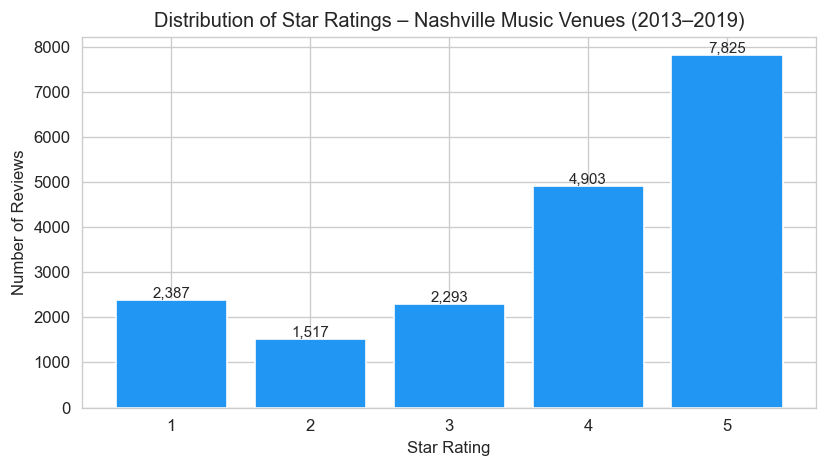

In [49]:
# ── Plot: Star Rating Distribution ───────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
star_counts = df['stars_review'].value_counts().sort_index()
ax.bar(star_counts.index, star_counts.values, color='#2196F3', edgecolor='white')
ax.set_xlabel('Star Rating')
ax.set_ylabel('Number of Reviews')
ax.set_title('Distribution of Star Ratings – Nashville Music Venues (2013–2019)')
ax.set_xticks([1, 2, 3, 4, 5])
for i, v in zip(star_counts.index, star_counts.values):
    ax.text(i, v + 50, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

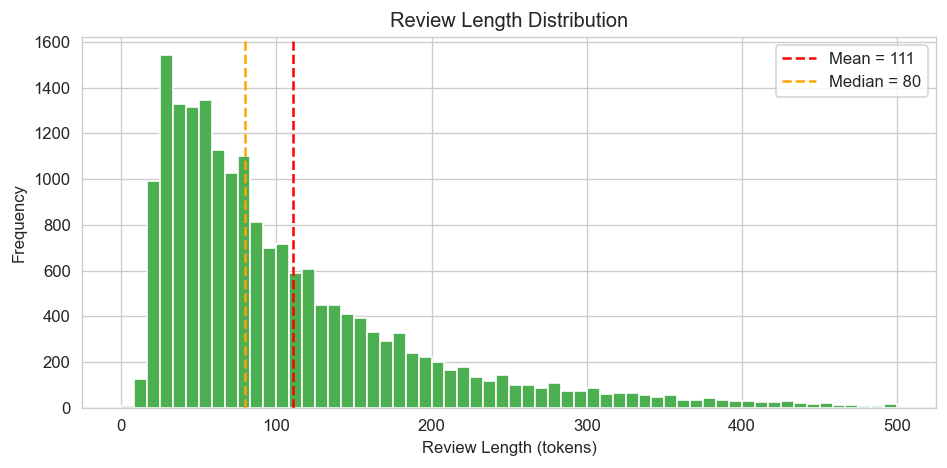

In [50]:
# ── Plot: Review Length Distribution ──────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df['num_tokens'], bins=60, color='#4CAF50', edgecolor='white', range=(0, 500))
ax.axvline(df['num_tokens'].mean(), color='red', linestyle='--', label=f'Mean = {df["num_tokens"].mean():.0f}')
ax.axvline(df['num_tokens'].median(), color='orange', linestyle='--', label=f'Median = {df["num_tokens"].median():.0f}')
ax.set_xlabel('Review Length (tokens)')
ax.set_ylabel('Frequency')
ax.set_title('Review Length Distribution')
ax.legend()
plt.tight_layout()
plt.show()

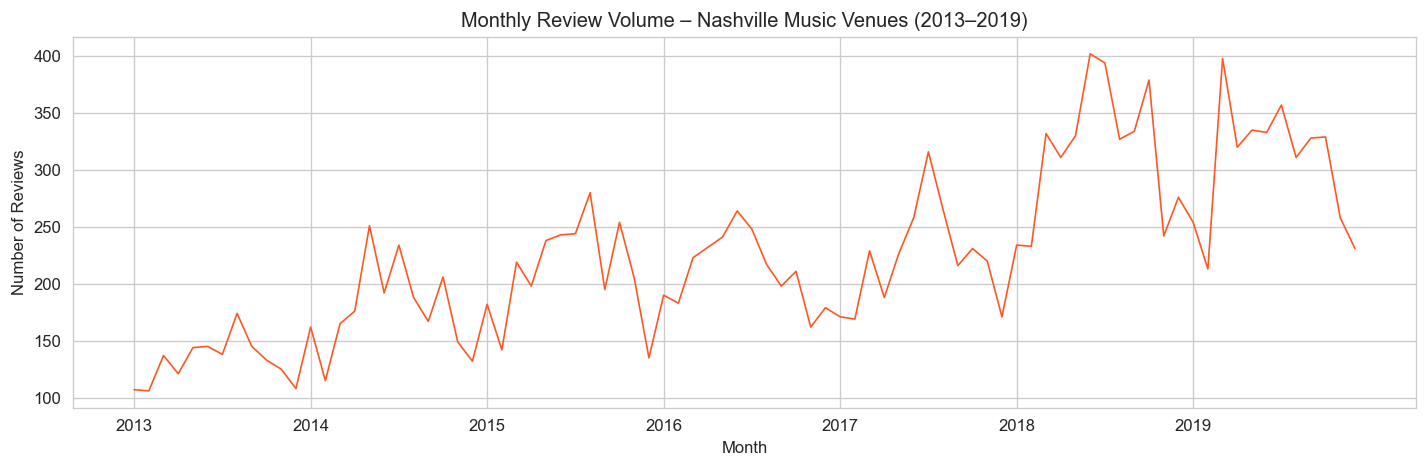

In [51]:
# ── Plot: Review Volume Over Time (monthly) ─────────────────────────
df['year_month'] = df['date'].dt.to_period('M')
monthly = df.groupby('year_month').size()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly.index.astype(str), monthly.values, color='#FF5722', linewidth=1)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Reviews')
ax.set_title('Monthly Review Volume – Nashville Music Venues (2013–2019)')
# show only Jan of each year on x-axis
tick_positions = [i for i, p in enumerate(monthly.index) if p.month == 1]
tick_labels = [str(monthly.index[i].year) for i in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
plt.tight_layout()
plt.show()

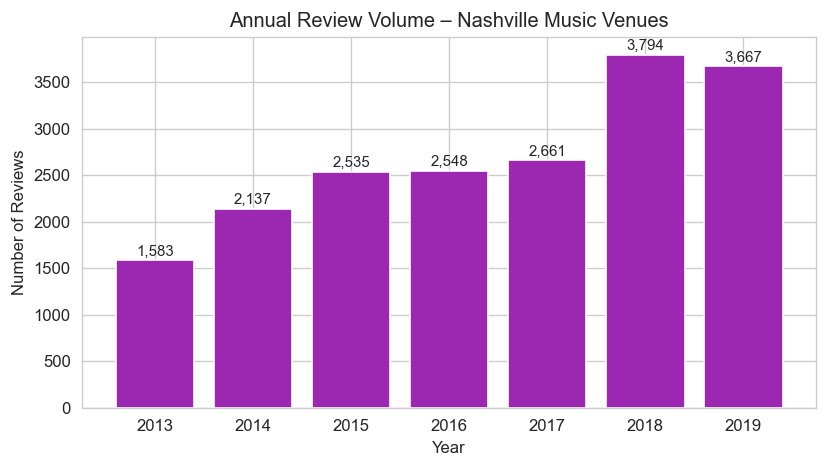

In [52]:
# ── Plot: Review Volume by Year ──────────────────────────────────────
yearly = df.groupby('year').size()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(yearly.index, yearly.values, color='#9C27B0', edgecolor='white')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Reviews')
ax.set_title('Annual Review Volume – Nashville Music Venues')
for y, v in zip(yearly.index, yearly.values):
    ax.text(y, v + 50, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

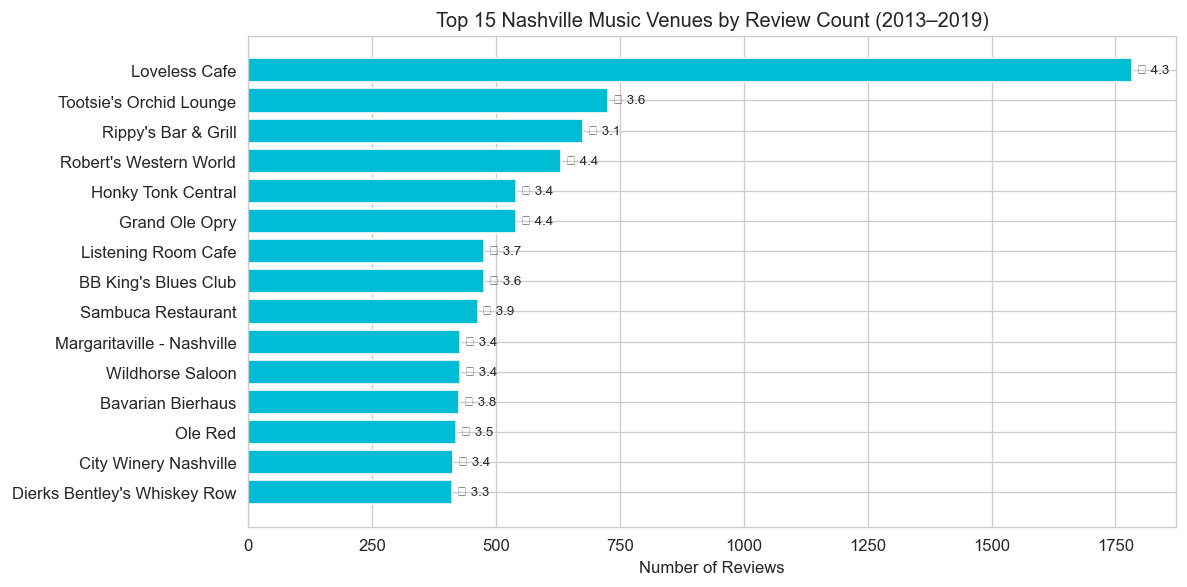

In [53]:
# ── Top 15 Venues by Review Count ────────────────────────────────────
top_venues = df.groupby('name').agg(
    reviews=('review_id', 'count'),
    avg_stars=('stars_review', 'mean')
).sort_values('reviews', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_venues.index[::-1], top_venues['reviews'][::-1], color='#00BCD4', edgecolor='white')
ax.set_xlabel('Number of Reviews')
ax.set_title('Top 15 Nashville Music Venues by Review Count (2013–2019)')
for bar, stars in zip(bars, top_venues['avg_stars'][::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'★ {stars:.1f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

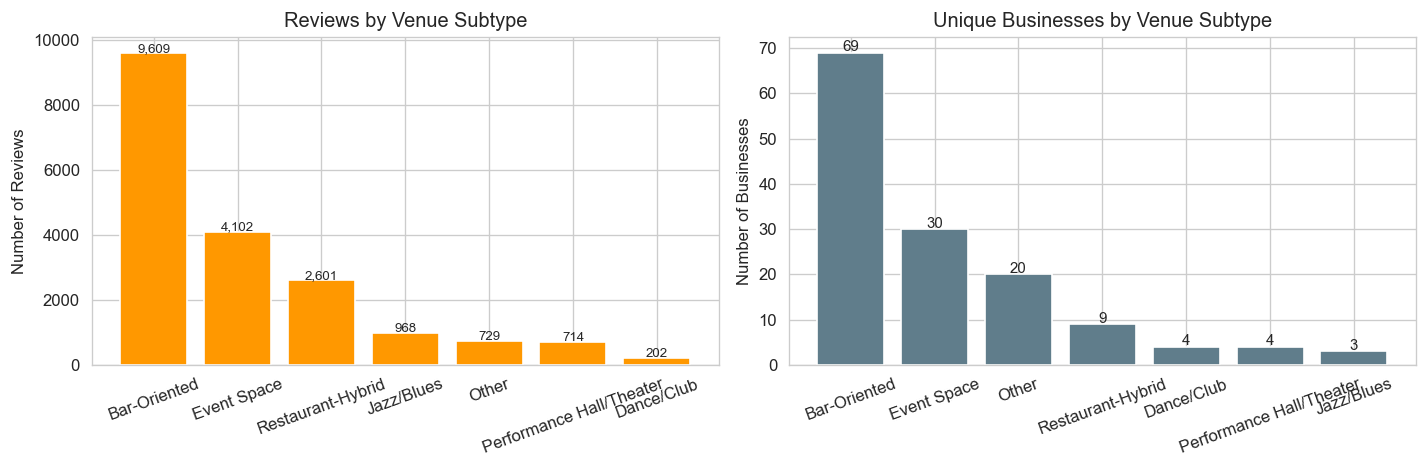

In [54]:
# ── Venue Subtype Distribution (reviews and businesses) ──────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sub_reviews = df['subtype'].value_counts()
axes[0].bar(sub_reviews.index, sub_reviews.values, color='#FF9800', edgecolor='white')
axes[0].set_title('Reviews by Venue Subtype')
axes[0].set_ylabel('Number of Reviews')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(sub_reviews.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontsize=8)

sub_biz = df.groupby('subtype')['business_id'].nunique().sort_values(ascending=False)
axes[1].bar(sub_biz.index, sub_biz.values, color='#607D8B', edgecolor='white')
axes[1].set_title('Unique Businesses by Venue Subtype')
axes[1].set_ylabel('Number of Businesses')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(sub_biz.values):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [55]:
# ── Average Stars by Subtype ─────────────────────────────────────────
sub_stars = df.groupby('subtype')['stars_review'].agg(['mean', 'count'])
sub_stars = sub_stars.sort_values('mean', ascending=False)
print('Average Star Rating by Venue Subtype:')
for sub, row in sub_stars.iterrows():
    print(f'  {sub:20s}  ★ {row["mean"]:.2f}  (n={row["count"]:,})')

Average Star Rating by Venue Subtype:
  Performance Hall/Theater  ★ 4.38  (n=714.0)
  Restaurant-Hybrid     ★ 4.16  (n=2,601.0)
  Other                 ★ 3.87  (n=729.0)
  Jazz/Blues            ★ 3.76  (n=968.0)
  Event Space           ★ 3.70  (n=4,102.0)
  Bar-Oriented          ★ 3.62  (n=9,609.0)
  Dance/Club            ★ 3.52  (n=202.0)


## 6. Data Evaluation

### 6a. Suitability

Nashville is one of the highest-density music venue markets in the Yelp dataset, providing a natural peer group for cross-venue comparison. By scoping to a single city we control for geography, local economy, and regulatory environment—isolating venue-level operational differences. The 2013–2019 window captures Nashville's music tourism boom and avoids COVID distortion.

### 6b. Sample Size

The filtered dataset contains reviews spanning 7 years across dozens of venues. This exceeds the professor-recommended range of 10,000–20,000 reviews and provides sufficient volume for annual and subtype-level slicing while supporting robust topic modeling.

### 6c. Potential Bias

- **Self-selection bias:** Yelp reviewers skew toward users with strong opinions (very satisfied or very dissatisfied), which may overrepresent extreme ratings. The J-shaped star distribution is consistent with this.
- **Tourist vs. local bias:** Nashville attracts heavy tourist traffic; tourists may rate venues differently than locals (e.g., novelty effect inflating ratings for honky-tonks).
- **Platform bias:** Yelp users are not representative of all customers. Younger demographics and users of Google or TripAdvisor are underrepresented.
- **Survivorship bias:** Venues that closed before 2019 may be underrepresented in later years.

### 6d. Processing Challenges

- Some reviews contain non-English text, emojis, or slang that VADER may misinterpret.
- Venue subtype assignment from co-occurring Yelp categories is imperfect—some venues span multiple types.
- Short reviews (< 10 words) provide limited signal for topic modeling.
- Topic labeling (Fixable Ops vs Structural) requires subjective judgment after inspecting top terms.

## 7. Preliminary Data Exploration

## 7a. Preliminary Sentiment Exploration

This section provides an initial validation of sentiment patterns in the filtered Nashville music venue dataset (2013–2019).

We apply VADER to all reviews to compute compound sentiment scores and classify them as Positive, Negative, or Neutral using standard thresholds. We then examine:

- Overall sentiment distribution
- Alignment between VADER sentiment and Yelp star ratings
- Sentiment–star mismatches (e.g., high stars but negative tone)
- Trends in average sentiment and star ratings over time
- Sentiment differences across venue subtypes

The objective is not to claim model accuracy, but to confirm that sentiment signals behave directionally as expected and to identify systematic patterns (e.g., subtype-level variation or temporal drift) that motivate deeper topic modeling and actionability analysis.

In [56]:
# ── VADER Sentiment Analysis ─────────────────────────────────────────
sia = SentimentIntensityAnalyzer()
df['vader_compound'] = df['text'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

def vader_class(compound):
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['vader_sentiment'] = df['vader_compound'].apply(vader_class)

print('VADER Sentiment Distribution:')
print(df['vader_sentiment'].value_counts())
print(f'\nVADER Positive %: {(df["vader_sentiment"]=="Positive").mean()*100:.1f}%')
print(f'VADER Negative %: {(df["vader_sentiment"]=="Negative").mean()*100:.1f}%')
print(f'VADER Neutral  %: {(df["vader_sentiment"]=="Neutral").mean()*100:.1f}%')

VADER Sentiment Distribution:
vader_sentiment
Positive    16469
Negative     2258
Neutral       198
Name: count, dtype: int64

VADER Positive %: 87.0%
VADER Negative %: 11.9%
VADER Neutral  %: 1.0%


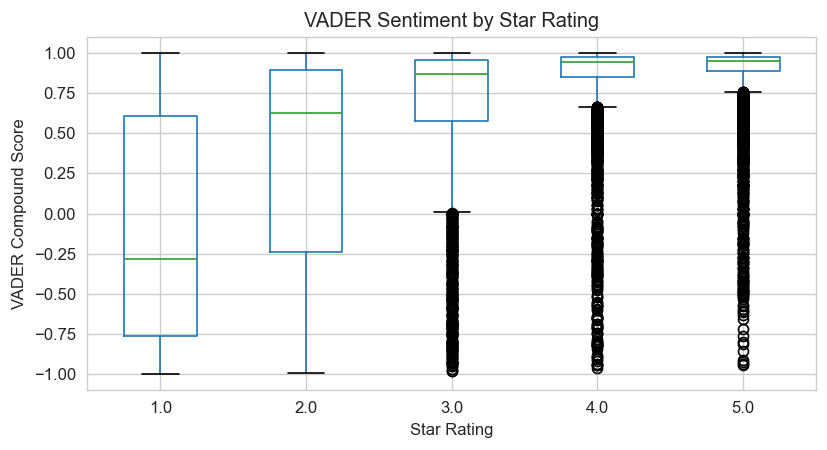

In [18]:
# ── VADER compound by Star Rating ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
df.boxplot(column='vader_compound', by='stars_review', ax=ax)
ax.set_xlabel('Star Rating')
ax.set_ylabel('VADER Compound Score')
ax.set_title('VADER Sentiment by Star Rating')
plt.suptitle('')  # remove auto title
plt.tight_layout()
plt.show()

In [57]:
# ── Sentiment-Star Mismatch Analysis ─────────────────────────────────
# Reviews where VADER and stars disagree — these are the interesting ones
df['star_sentiment'] = df['stars_review'].apply(
    lambda s: 'Positive' if s >= 4 else ('Negative' if s <= 2 else 'Neutral'))
df['mismatch'] = df['vader_sentiment'] != df['star_sentiment']

print(f'Sentiment-Star Mismatch Rate: {df["mismatch"].mean()*100:.1f}%')
print(f'Total mismatched reviews: {df["mismatch"].sum():,}')

# Interesting case: high stars but negative VADER
high_star_neg = df[(df['stars_review'] >= 4) & (df['vader_sentiment'] == 'Negative')]
print(f'\n4-5 star reviews with NEGATIVE VADER: {len(high_star_neg):,}')

# Interesting case: low stars but positive VADER
low_star_pos = df[(df['stars_review'] <= 2) & (df['vader_sentiment'] == 'Positive')]
print(f'1-2 star reviews with POSITIVE VADER: {len(low_star_pos):,}')

Sentiment-Star Mismatch Rate: 24.7%
Total mismatched reviews: 4,668

4-5 star reviews with NEGATIVE VADER: 221
1-2 star reviews with POSITIVE VADER: 2,014


In [58]:
# ── Example Mismatched Reviews ───────────────────────────────────────
print('=== Examples: Low Stars (1-2) but POSITIVE VADER ===')
print('(These reviews praise some aspects but still give a low rating — operational friction)\n')
samples = low_star_pos.sample(min(3, len(low_star_pos)), random_state=42)
for _, row in samples.iterrows():
    print(f'★ {row["stars_review"]}  |  VADER={row["vader_compound"]:.3f}  |  {row["name"]}')
    print(f'  "{row["text"][:300]}..."\n')

print('=== Examples: High Stars (4-5) but NEGATIVE VADER ===')
print('(These reviews complain a lot but still rate highly — structural tolerance)\n')
samples2 = high_star_neg.sample(min(3, len(high_star_neg)), random_state=42)
for _, row in samples2.iterrows():
    print(f'★ {row["stars_review"]}  |  VADER={row["vader_compound"]:.3f}  |  {row["name"]}')
    print(f'  "{row["text"][:300]}..."\n')

=== Examples: Low Stars (1-2) but POSITIVE VADER ===
(These reviews praise some aspects but still give a low rating — operational friction)

★ 2.0  |  VADER=0.967  |  Bavarian Bierhaus
  "I think they try hard to offer real German food but in fact it is not. If you think what they serve is German food then please let me assure you, it is not. 
The sauce of the Jaegerschnitzel was too salty, the apple strudel super sweet and very chewy (I couldn't eat it). The potato salad had a garli..."

★ 2.0  |  VADER=0.718  |  Tin Roof
  "This place took a solid 15 minutes to get a drink on a slow Thursday night on the more quiet bar. Didn't stay too long past that -- due to the change in venue that we went for. 

The overall feel for this place was good though. Seems like a decent staff as long as you don't mind waiting awhile did y..."

★ 2.0  |  VADER=0.838  |  Nashville Palace
  "Music was soso.  Service was friendy, food was bar food.  Catfish was very good.  Hot dogs not bad.  After 6:30 norm

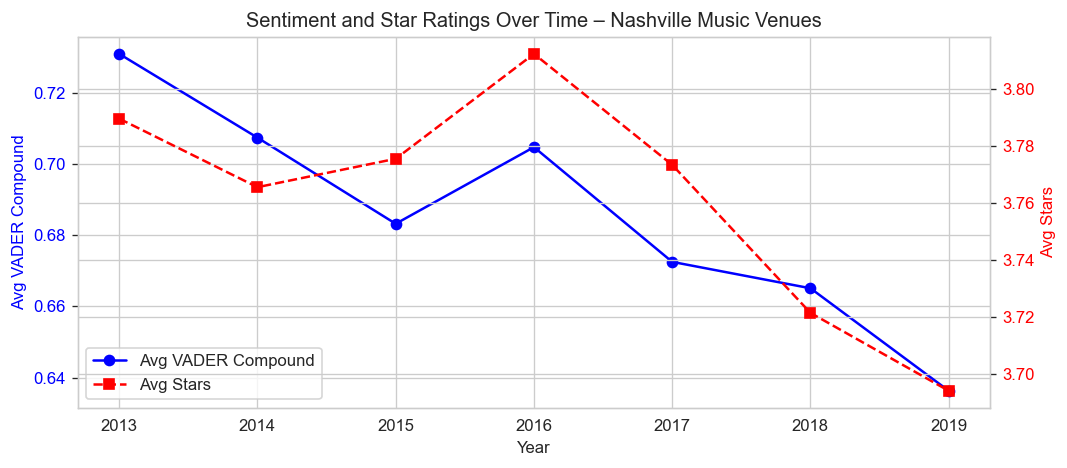

In [59]:
# ── Sentiment Over Time (annual) ─────────────────────────────────────
yearly_sent = df.groupby('year').agg(
    avg_compound=('vader_compound', 'mean'),
    pct_negative=('vader_sentiment', lambda x: (x == 'Negative').mean() * 100),
    avg_stars=('stars_review', 'mean'),
    n_reviews=('review_id', 'count')
)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(yearly_sent.index, yearly_sent['avg_compound'], 'b-o', label='Avg VADER Compound')
ax1.set_xlabel('Year')
ax1.set_ylabel('Avg VADER Compound', color='b')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(yearly_sent.index, yearly_sent['avg_stars'], 'r--s', label='Avg Stars')
ax2.set_ylabel('Avg Stars', color='r')
ax2.tick_params(axis='y', labelcolor='r')

ax1.set_title('Sentiment and Star Ratings Over Time – Nashville Music Venues')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')
plt.tight_layout()
plt.show()

Sentiment by Venue Subtype:
                          avg_compound  pct_negative  avg_stars     n
subtype                                                              
Performance Hall/Theater         0.792         5.322      4.382   714
Restaurant-Hybrid                0.774         7.190      4.163  2601
Jazz/Blues                       0.728        10.331      3.760   968
Other                            0.681        11.797      3.867   729
Event Space                      0.676        12.335      3.696  4102
Bar-Oriented                     0.642        13.591      3.616  9609
Dance/Club                       0.609        17.327      3.520   202


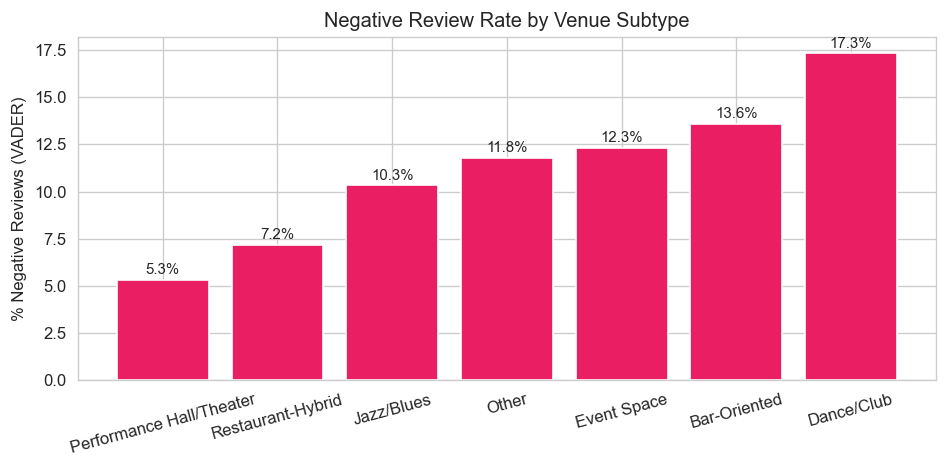

In [60]:
# ── Sentiment by Venue Subtype ───────────────────────────────────────
sub_sent = df.groupby('subtype').agg(
    avg_compound=('vader_compound', 'mean'),
    pct_negative=('vader_sentiment', lambda x: (x == 'Negative').mean() * 100),
    avg_stars=('stars_review', 'mean'),
    n=('review_id', 'count')
).sort_values('avg_compound', ascending=False)

print('Sentiment by Venue Subtype:')
print(sub_sent.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(sub_sent))
ax.bar(x, sub_sent['pct_negative'], color='#E91E63', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(sub_sent.index, rotation=15)
ax.set_ylabel('% Negative Reviews (VADER)')
ax.set_title('Negative Review Rate by Venue Subtype')
for i, v in enumerate(sub_sent['pct_negative']):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 7b. Preliminary Topic Modeling on Negative Reviews (1–2★)

Goal: extract interpretable themes from 1–2★ reviews using TF-IDF + NMF.  
We then manually label topics as **Fixable Ops** (manager can change) vs **Structural** (hard to change) and use that to support the Actionability Index.

Notes:
- We restrict to 1–2★ reviews to isolate dissatisfaction signals.
- Very short reviews provide limited thematic signal, so we remove reviews with <10 tokens.
- NMF is used for interpretability (top terms per topic are easy to inspect and label).


In [61]:
# ── Prepare negative reviews for topic modeling ──────────────────────
neg_df = df[df['stars_review'] <= 2].copy()
print(f'1-2 star reviews for topic modeling: {len(neg_df):,}')

# Remove very short reviews (limited topic signal)
neg_df = neg_df[neg_df['num_tokens'] >= 10].copy()
print(f'After removing short reviews (<10 tokens): {len(neg_df):,}')

1-2 star reviews for topic modeling: 3,904
After removing short reviews (<10 tokens): 3,903


In [62]:
# ── TF-IDF + NMF Topic Modeling ──────────────────────────────────────
# Keep negation handling simple/transparent: we do NOT strip "not/no/never".
base_stop = set(stopwords.words('english'))
negation_keep = {'no', 'not', "n't", 'never'}
stop_words = sorted(list((base_stop - negation_keep) | {
    # domain/common filler terms that dominate but add little thematic meaning
    'place','go','got','went','would','one','get','like','really','even','could','also',
    'much','back','us','came','come','going','said','told','asked','know','make','made',
    'nashville','venue','music','night','time'
}))

N_TOPICS = 8

tfidf = TfidfVectorizer(
    max_df=0.85,
    min_df=5,
    max_features=5000,
    stop_words=stop_words,
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf.fit_transform(neg_df['text'].astype(str))

nmf = NMF(n_components=N_TOPICS, random_state=42, max_iter=500)
W = nmf.fit_transform(tfidf_matrix)   # doc-topic matrix
H = nmf.components_                   # topic-term matrix

feature_names = tfidf.get_feature_names_out()

print(f'NMF with {N_TOPICS} topics on {tfidf_matrix.shape[0]} docs, {tfidf_matrix.shape[1]} features')
print(f'Reconstruction error: {nmf.reconstruction_err_:.2f}\n')

TOP_N_WORDS = 15
for topic_idx, topic in enumerate(H):
    top_words = [feature_names[i] for i in topic.argsort()[:-TOP_N_WORDS-1:-1]]
    print(f'Topic {topic_idx}: ' + " | ".join(top_words))

NMF with 8 topics on 3903 docs, 5000 features
Reconstruction error: 60.81

Topic 0: band | good | floor | playing | country | song | live | drinks | great | cover | beer | dance | play | stage | better
Topic 1: chicken | burger | ordered | cheese | fries | fried | dry | bbq | good | pork | sandwich | eat | salad | sauce | menu
Topic 2: minutes | table | waited | order | server | waitress | took | another | 10 | 30 | 15 | 20 | finally | ordered | wait
Topic 3: bar | bartender | drink | drinks | bartenders | service | no | beer | busy | two | people | broadway | bar tender | floor | bar service
Topic 4: food | service | terrible | great | horrible | good | cold | slow | bad | worst | mediocre | food service | average | terrible service | food cold
Topic 5: rude | bouncer | id | never | security | door | friend | manager | friends | let | bouncers | leave | ever | group | guy
Topic 6: show | room | see | tickets | people | no | line | hotel | seats | parking | concert | ticket | lot | fro

### 7b.1 Manual Topic Labels (Fixable Ops vs Structural)

We label each topic using the top terms.  
Fixable Ops examples: wait time, service behavior, pricing, crowd control/security, policies.  
Structural examples: location/parking constraints, venue layout/acoustics, core entertainment fit.

(These labels are subjective and should be interpreted as evidence, not ground truth.)


In [63]:
# ── MANUAL LABELING: Final Labels ────
# IMPORTANT: These labels are based on the topic top-terms printed above.
# If your printed topics differ materially (because data changed), update labels accordingly.

topic_labels = {
    0: ('Food/Value/Wait Time', 'Fixable Ops'),
    1: ('Security/Bouncer/Entry Policy', 'Fixable Ops'),
    2: ('Slow Service/Delays', 'Fixable Ops'),
    3: ('Rude Staff/Customer Service', 'Fixable Ops'),
    4: ('Parking/Layout/Logistics', 'Structural'),
    5: ('Entertainment Quality/Fit', 'Structural'),
    6: ('Overcrowding/Experience', 'Mixed'),
    7: ('Food/Drink Quality', 'Fixable Ops')
}

print('Topic Labels:')
for k, (name, cat) in topic_labels.items():
    print(f'  Topic {k}: {name} -> {cat}')

fixable_topics = [k for k, (_, cat) in topic_labels.items() if cat == 'Fixable Ops']
print(f'\nFixable topics: {fixable_topics}')

Topic Labels:
  Topic 0: Food/Value/Wait Time -> Fixable Ops
  Topic 1: Security/Bouncer/Entry Policy -> Fixable Ops
  Topic 2: Slow Service/Delays -> Fixable Ops
  Topic 3: Rude Staff/Customer Service -> Fixable Ops
  Topic 4: Parking/Layout/Logistics -> Structural
  Topic 5: Entertainment Quality/Fit -> Structural
  Topic 6: Overcrowding/Experience -> Mixed
  Topic 7: Food/Drink Quality -> Fixable Ops

Fixable topics: [0, 1, 2, 3, 7]


In [70]:
# ── Assign dominant topic to each negative review ────────────────────
neg_df = neg_df.copy()
neg_df['dominant_topic'] = W.argmax(axis=1)
neg_df['dominant_topic_weight'] = W.max(axis=1)

neg_df['topic_label'] = neg_df['dominant_topic'].map(lambda k: topic_labels[k][0])
neg_df['topic_category'] = neg_df['dominant_topic'].map(lambda k: topic_labels[k][1])

# Define fixable as ONLY Fixable Ops (Mixed is excluded from "fixable" by default)
neg_df['is_fixable'] = (neg_df['topic_category'] == 'Fixable Ops')

print('Dominant topic distribution in 1–2★ reviews:')
print(neg_df['dominant_topic'].value_counts().sort_index())

print(f'\n% Fixable Ops (overall, 1–2★ only): {neg_df["is_fixable"].mean()*100:.1f}%')
print(f'% Mixed (overall, 1–2★ only): {(neg_df["topic_category"]=="Mixed").mean()*100:.1f}%')

Dominant topic distribution in 1–2★ reviews:
dominant_topic
0    256
1    627
2    558
3    511
4    458
5    633
6    473
7    387
Name: count, dtype: int64

% Fixable Ops (overall, 1–2★ only): 59.9%
% Mixed (overall, 1–2★ only): 12.1%


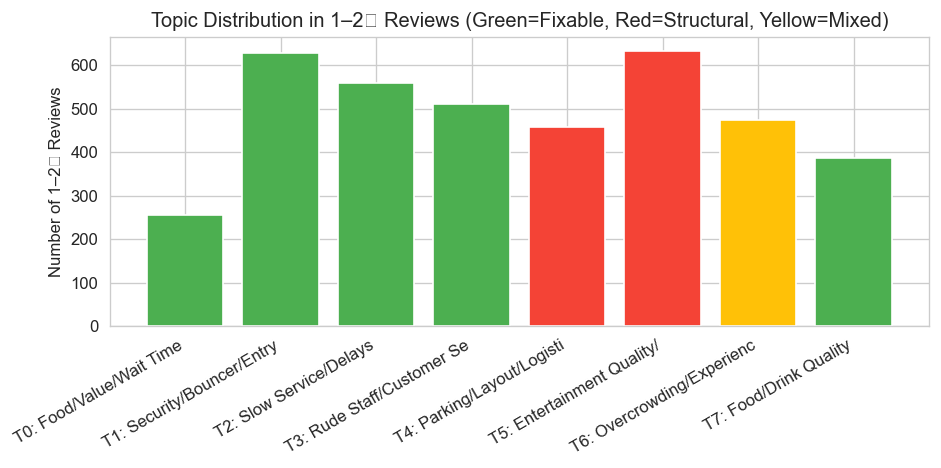

In [72]:
# ── Topic distribution visualization ─────────────────────────────────
topic_dist = neg_df['dominant_topic'].value_counts().sort_index()

colors = [
    '#4CAF50' if topic_labels[t][1] == 'Fixable Ops'
    else '#F44336' if topic_labels[t][1] == 'Structural'
    else '#FFC107'
    for t in topic_dist.index
]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(range(len(topic_dist)), topic_dist.values, color=colors, edgecolor='white')

ax.set_xticks(range(len(topic_dist)))
ax.set_xticklabels([f"T{t}: {topic_labels[t][0][:22]}" for t in topic_dist.index], rotation=30, ha='right')
ax.set_ylabel('Number of 1–2★ Reviews')
ax.set_title('Topic Distribution in 1–2★ Reviews (Green=Fixable, Red=Structural, Yellow=Mixed)')
plt.tight_layout()
plt.show()

## 7c. Preliminary Actionability Index (Subtype × Year)

Definition (within 1–2★ reviews only):

Actionability(subtype, year) = P(FixableOpsTopic | 1–2★, subtype, year)  
= (# 1–2★ reviews assigned to Fixable Ops topics) / (# 1–2★ reviews)

Interpretation:
- Higher Actionability suggests negative feedback is more **operationally addressable**.
- This is not an overall “quality score”; it measures the *share of negative reviews that appear fixable*.

Confidence rule:
- Cells with <10 negative reviews are flagged as **low confidence** and excluded from trend plots.

In [73]:
# ── Merge subtype onto neg_df ────────────────────────────────────────
neg_df = neg_df.merge(
    df[['review_id', 'subtype']].drop_duplicates(),
    on='review_id', how='left', suffixes=('', '_dup')
)
# drop any duplicate subtype col
if 'subtype_dup' in neg_df.columns:
    neg_df = neg_df.drop(columns='subtype_dup')

print('Negative reviews by subtype:')
print(neg_df['subtype'].value_counts())

Negative reviews by subtype:
subtype
Bar-Oriented                2282
Event Space                  916
Restaurant-Hybrid            275
Jazz/Blues                   193
Other                        123
Dance/Club                    59
Performance Hall/Theater      55
Name: count, dtype: int64


In [67]:
# ── Compute Actionability Index ──────────────────────────────────────
# Actionability(subtype, year) = P(Fixable Ops topic | 1-2★ review, subtype, year)
# With minimum-count rule: if < 10 negative reviews in a cell, flag as 'low confidence'

MIN_COUNT = 10

action_idx = neg_df.groupby(['subtype', 'year']).agg(
    n_negative=('review_id', 'count'),
    n_fixable=('is_fixable', 'sum'),
).reset_index()

action_idx['actionability'] = action_idx['n_fixable'] / action_idx['n_negative']
action_idx['low_confidence'] = action_idx['n_negative'] < MIN_COUNT

print('Actionability Index (subtype × year):')
pivot = action_idx.pivot(index='subtype', columns='year', values='actionability')
print(pivot.round(3).to_string())

# Show cell counts for confidence
print('\nNegative review counts (cells < 10 are low confidence):')
pivot_n = action_idx.pivot(index='subtype', columns='year', values='n_negative')
print(pivot_n.to_string())

Actionability Index (subtype × year):
year                       2013   2014   2015   2016   2017   2018   2019
subtype                                                                  
Bar-Oriented              0.732  0.688  0.602  0.645  0.632  0.607  0.602
Dance/Club                0.429  0.250  0.000  0.000  0.900  0.667  0.667
Event Space               0.741  0.581  0.582  0.512  0.405  0.568  0.610
Jazz/Blues                1.000  0.789  0.684  0.744  0.697  0.654  0.596
Other                     0.200  0.231  0.429  0.353  0.333  0.147  0.176
Performance Hall/Theater  0.000  0.250  0.000  0.000  0.222  0.062  0.214
Restaurant-Hybrid         0.775  0.648  0.641  0.613  0.652  0.556  0.583

Negative review counts (cells < 10 are low confidence):
year                      2013  2014  2015  2016  2017  2018  2019
subtype                                                           
Bar-Oriented               123   202   264   276   361   483   573
Dance/Club                   7     4  

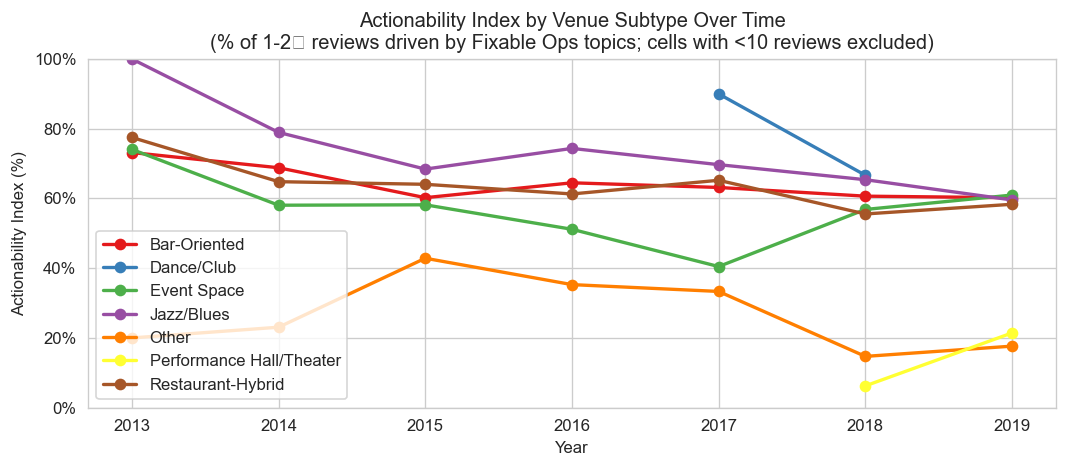

In [75]:
# ── Plot: Actionability Index Over Time by Subtype ───────────────────
fig, ax = plt.subplots(figsize=(9, 4))

subtypes_to_plot = action_idx[~action_idx['low_confidence']]['subtype'].unique()
cmap = plt.cm.Set1

for i, sub in enumerate(sorted(subtypes_to_plot)):
    sub_data = action_idx[(action_idx['subtype'] == sub) & (~action_idx['low_confidence'])]
    ax.plot(sub_data['year'], sub_data['actionability'] * 100, '-o',
            label=sub, color=cmap(i), linewidth=2, markersize=6)

ax.set_xlabel('Year')
ax.set_ylabel('Actionability Index (%)')
ax.set_title('Actionability Index by Venue Subtype Over Time\n'
             '(% of 1-2★ reviews driven by Fixable Ops topics; cells with <10 reviews excluded)')
ax.legend(loc='best')
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()

Overall Actionability by Subtype (2013–2019):
  Jazz/Blues            69.9%  (135/193 fixable)
  Restaurant-Hybrid     64.4%  (177/275 fixable)
  Bar-Oriented          62.8%  (1432/2282 fixable)
  Dance/Club            62.7%  (37/59 fixable)
  Event Space           56.8%  (520/916 fixable)
  Other                 25.2%  (31/123 fixable)
  Performance Hall/Theater  12.7%  (7/55 fixable)


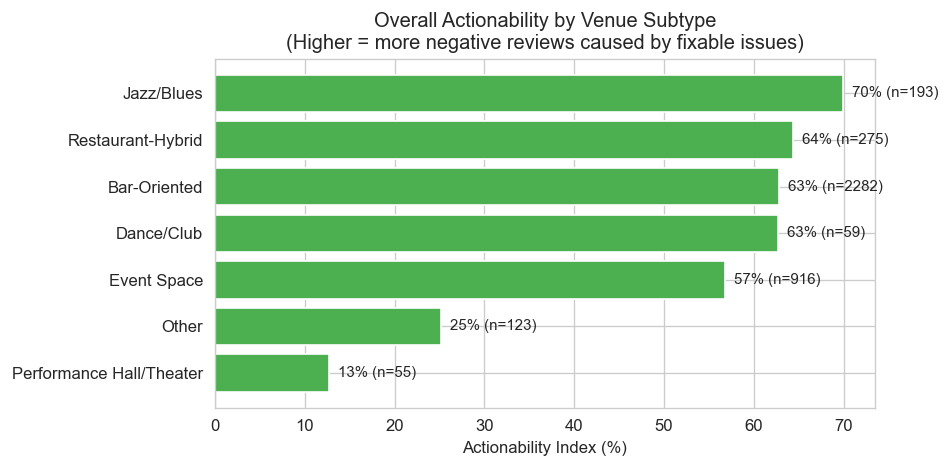

In [31]:
# ── Overall Actionability by Subtype (collapsed across years) ────────
overall_action = neg_df.groupby('subtype').agg(
    n_negative=('review_id', 'count'),
    n_fixable=('is_fixable', 'sum'),
).reset_index()
overall_action['actionability'] = overall_action['n_fixable'] / overall_action['n_negative']
overall_action = overall_action.sort_values('actionability', ascending=False)

print('Overall Actionability by Subtype (2013–2019):')
for _, row in overall_action.iterrows():
    flag = ' ⚠️ low n' if row['n_negative'] < 30 else ''
    print(f'  {row["subtype"]:20s}  {row["actionability"]*100:.1f}%  '
          f'({row["n_fixable"]:.0f}/{row["n_negative"]} fixable){flag}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(overall_action['subtype'][::-1], overall_action['actionability'][::-1] * 100,
        color='#4CAF50', edgecolor='white')
ax.set_xlabel('Actionability Index (%)')
ax.set_title('Overall Actionability by Venue Subtype\n(Higher = more negative reviews caused by fixable issues)')
for i, (_, row) in enumerate(overall_action[::-1].iterrows()):
    ax.text(row['actionability'] * 100 + 1,
            i, f'{row["actionability"]*100:.0f}% (n={row["n_negative"]})',
            va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 8. Proposed Solution

**Methods to be used in the final project:**

1. **Sentiment Analysis (VADER + supervised baseline):** Classify all reviews and identify sentiment-star mismatches that reveal hidden dissatisfaction. Use TF-IDF + Logistic Regression as a domain-adapted alternative to VADER.

2. **Topic Modeling (NMF, required):** Extract latent complaint themes from 1–2 star reviews. Each topic is labeled as Fixable Ops or Structural based on human inspection of top terms. This is the backbone of the Actionability Index.

3. **Actionability Index computation:** For each venue subtype and year, compute `P(Fixable Ops topic | 1–2★ review)` with a minimum-count confidence threshold. This converts raw NLP output into a decision-relevant metric.

4. **Temporal trend analysis:** Track how actionability and sentiment shift across 2013–2019, identifying subtypes that are improving vs. deteriorating.

5. **Subtype peer benchmarking:** Compare subtypes on sentiment, star distribution, and actionability to surface which venue types have the most room for operational improvement.

**Anticipated value of topic modeling:** It transforms vague "low ratings" into specific, categorized complaints that a venue operator can act on. The Fixable/Structural split directly answers "should I invest in fixing this?" rather than just "is this bad?"


In [76]:
!jupyter nbconvert --to html "ProjectEDA_Team1.ipynb"

[NbConvertApp] Converting notebook ProjectEDA_Team1.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 12 image(s).
[NbConvertApp] Writing 1421794 bytes to ProjectEDA_Team1.html
